In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# MachineMoo Imports
from machinemoo.scalarization.examples.logistic_fair import FairLogRegMO
from machinemoo.scalarization.lipschitz_estimation import calculate_logreg_lipschitz_constant
from machinemoo.moo.core import MachineMoo, get_objectives, get_history_objectives
from machinemoo.moo.random_weights import RandomWeights
from machinemoo.moo.monise import MONISE
from machinemoo.moo.mola import MOLA
from machinemoo.moo.nise import NISE

# Utils
from machinemoo.analysis.filters import filter_dominated

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
# Load dataset
# Ensure the path is correct relative to your notebook
BASE_DIR = Path(r".").resolve()
df = pd.read_csv(BASE_DIR / 'dataset/compas_onerace.csv')

# Drop unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Define features
fair_feature = 'not_white'
pred_feature = 'Two_yr_Recidivism'

print(f"Dataset loaded. Shape: {df.shape}")

# Preprocessing
X = df.drop([pred_feature], axis=1)
# Normalize target to 0/1 (if not already)
y = (df[pred_feature] + 1) // 2 

# Stratified split to maintain class/group balance
# Create a stratification key based on target + sensitive attribute
stratify_col = y.astype(str) + "_" + X[fair_feature].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, # As per your original notebook
    stratify=stratify_col,
)

# Scaling is important for Logistic Regression convergence
scaler = StandardScaler()
# Keep as DataFrames to preserve column names for LogRegScalarization
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
# Restore the binary sensitive feature to 0/1 (scaling might have shifted it)
# This is crucial because LogRegScalarization uses unique values of fair_feat
X_train[fair_feature] = X.loc[X_train.index, fair_feature]

X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
X_test[fair_feature] = X.loc[X_test.index, fair_feature]

print(f"Training set size: {len(X_train)}")

Dataset loaded. Shape: (6172, 7)
Training set size: 4320


In [3]:
common_opt_params = {
    'target_size': 10000000000,
    'time_limit': 10, 
}
IP_opt_params={**common_opt_params, 'node_gap': 0.01, 'node_time_limit': 1.0}

scalarizer_zero = FairLogRegMO(
    num_objs=2, 
    X=X_train,
    y=y_train,
    fair_feat=fair_feature,
    max_iter=1,
    tol=1e-10, 
    lower_bound_estimate="zero"
)

scalarizer_lipschitz = FairLogRegMO(
    num_objs=2, 
    X=X_train,
    y=y_train,
    fair_feat=fair_feature,
    max_iter=3,
    tol=1e-10,
    lower_bound_estimate="lipschitz"
)

machine_moo_zero = MachineMoo(scalarizer_zero, scalarizer_zero)
machine_moo_lipschitz = MachineMoo(scalarizer_lipschitz, scalarizer_lipschitz)

common_scalarizer_params = {
    # Any common params can go here
    'max_iter': 1,
    'tol': 1e-4
}

results = {}
print("Running NISE...\n")
results['NISE'] = machine_moo_zero.run(NISE, common_opt_params)

print("Running NISE-Lip...\n")
results['NISE-Lip'] = machine_moo_lipschitz.run(NISE, common_opt_params)

print("Running Random Weights...\n")
results['RW-Lip'] = machine_moo_lipschitz.run(RandomWeights, common_opt_params)

#print("Running MONISE...\n")
#results['MONISE-Lip'] = machine_moo_lipschitz.run(MONISE, common_opt_params)

#print("Running MOLA-Lip...\n")
#results['MOLA-Lip'] = machine_moo_lipschitz.run(MOLA, common_opt_params)

Running NISE...



/home/marcos/Documents/Experimentos/machinemoo/machinemoo/moo/nise.py:84: RuntimeWarning: invalid value encountered in matmul
  best_obj = self.w @ self.weighted_scalar.objs
/home/marcos/Documents/Experimentos/machinemoo/machinemoo/moo/nise.py:84: RuntimeWarning: invalid value encountered in matmul
  best_obj = self.w @ self.weighted_scalar.objs
/home/marcos/Documents/Experimentos/machinemoo/machinemoo/moo/nise.py:84: RuntimeWarning: invalid value encountered in matmul
  best_obj = self.w @ self.weighted_scalar.objs
/home/marcos/Documents/Experimentos/machinemoo/machinemoo/moo/nise.py:84: RuntimeWarning: invalid value encountered in matmul
  best_obj = self.w @ self.weighted_scalar.objs
/home/marcos/Documents/Experimentos/machinemoo/machinemoo/moo/nise.py:84: RuntimeWarning: invalid value encountered in matmul
  best_obj = self.w @ self.weighted_scalar.objs
/home/marcos/Documents/Experimentos/machinemoo/machinemoo/moo/nise.py:84: RuntimeWarning: invalid value encountered in matmul
  be

Running NISE-Lip...

Running Random Weights...



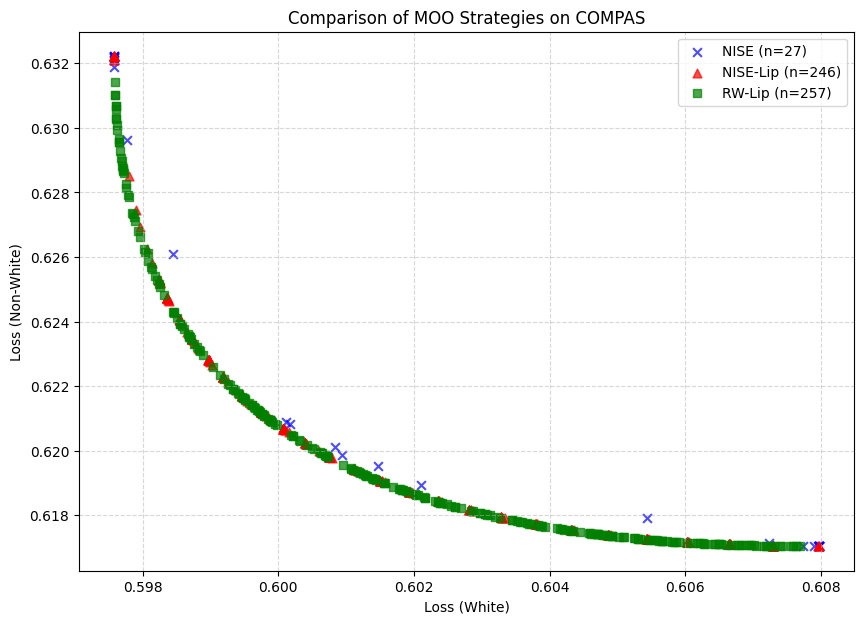


Runtime Comparison:
NISE: 10.01 s
NISE-Lip: 10.03 s
RW-Lip: 10.03 s


In [4]:
plt.figure(figsize=(10, 7))

colors = {'RW': 'gray', 'NISE': 'blue', 'NISE-Lip': 'red', 'RW-Lip': 'green', 'MONISE-Lip': 'orange', 'MOLA-Lip': 'orange'}
markers = {'RW': 'o', 'NISE': 'x', 'NISE-Lip': '^', 'RW-Lip': 's', 'MONISE-Lip': 'D', 'MOLA-Lip': 'D'}

for key, res in results.items():
    objs = get_objectives(res)
    plt.scatter(
        objs[:, 0], objs[:, 1], 
        label=f"{key} (n={len(objs)})", 
        c=colors[key], marker=markers[key], s=40, alpha=0.7 
    )

plt.xlabel('Loss (White)')
plt.ylabel('Loss (Non-White)')
plt.title('Comparison of MOO Strategies on COMPAS')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Print Runtimes
print("\nRuntime Comparison:")
for key, res in results.items():
    print(f"{key}: {res.fit_runtime:.2f} s")

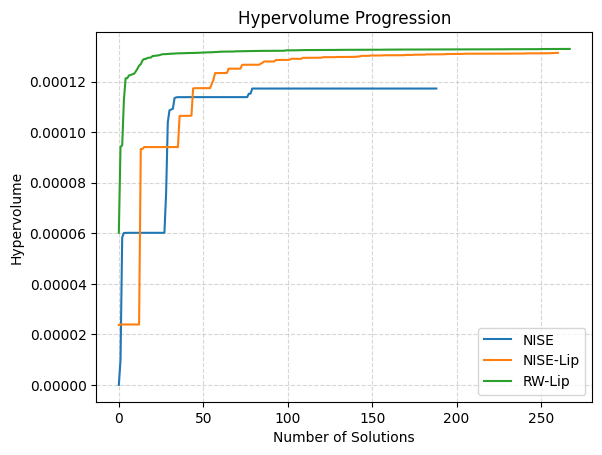

In [5]:
from machinemoo.analysis.metrics import compute_hypervolume_progress

reference_point = np.array([-np.inf, -np.inf])  # Adjust based on your objective scales
for key, res in results.items():
    objs = get_objectives(res)
    reference_point = np.maximum(reference_point, objs.max(axis=0))

for key, res in results.items():
    objs = get_history_objectives(res)
    hv_values = compute_hypervolume_progress(objs, reference_point)
    plt.plot(hv_values, label=key)

plt.xlabel('Number of Solutions')
plt.ylabel('Hypervolume')
plt.title('Hypervolume Progression')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [6]:
from machinemoo.scalarization.examples.mlp import MLPScalarization

In [7]:
num_objs = 2
epochs = 3

general_cfg = {"target_size": 1000, "time_limit": 10}
ip_cfg = {"node_time_limit": 2, "node_gap": 0.05}
#merge configs
ip_cfg = {**general_cfg, **ip_cfg}

results = {}

print("--- Rodando Experimentos ---")
sc_zero = MLPScalarization(num_objs, X_train, y_train, fair_feature, epochs, lower_bound_estimate="zero")
sc_lip = MLPScalarization(num_objs, X_train, y_train, fair_feature, epochs, lower_bound_estimate="lipschitz")
# calculate and print initial objectives
sc_zero.optimize(np.array([0.5, 0.5]))
sc_lip.optimize(np.array([0.5, 0.5]))
print(sc_zero.objs)
print(sc_lip.objs)
# intialize scalarizer running 100 epochs and uniform weights
for i in range(500//epochs):
    sc_zero.optimize(np.array([0.5, 0.5]))
    sc_lip.optimize(np.array([0.5, 0.5]))
print(sc_zero.objs)
print(sc_lip.objs)

--- Rodando Experimentos ---
[0.68548852 0.68546164]
[0.72831488 0.71345282]
[0.67914289 0.68196815]
[0.71444792 0.70699328]


In [8]:
# 3. MONISE (Lipschitz)
print("\nMONISE (Lipschitz)...")
# A única mudança é o parâmetro lower_bound_estimate
handler = MachineMoo(weighted_scalar=sc_lip)
results['MONISE-Lip'] = handler.run(MONISE, kwargs=ip_cfg)


MONISE (Lipschitz)...
MONISE Initialization:
[1. 0.]
Before optimize
[0.71444792 0.70699328]
[0.69839922 0.69793258]
After optimize
[0.71435827 0.70696509]
[0.69837469 0.69791553]
----
[0. 1.]
Before optimize
[0.71435827 0.70696509]
[0.69837469 0.69791553]
After optimize
[0.71430403 0.70692623]
[0.69834689 0.69788578]
----
MONISE Initialization:
[1. 0.]
Before optimize
[0.71430403 0.70692623]
[0.69834689 0.69788578]
After optimize
[0.71421468 0.70689827]
[0.69832183 0.69786888]
----
[0. 1.]
Before optimize
[0.71421468 0.70689827]
[0.69832183 0.69786888]
After optimize
[0.71416056 0.70685941]
[0.69829017 0.69783907]
----
[0.5 0.5]
[0.71408904 0.70682609]
[0.6982618  0.69781575]
----
MONISE Initialization:
[1. 0.]
Before optimize
[0.71408904 0.70682609]
[0.6982618  0.69781575]
After optimize
[0.71400005 0.7067982 ]
[0.69822497 0.69780097]
----
[0. 1.]
Before optimize
[0.71400005 0.7067982 ]
[0.69822497 0.69780097]
After optimize
[0.71394628 0.70675951]
[0.69819372 0.69777126]
----
[0.5 

In [9]:
print("Running NISE (Lipschitz)...")
machine_moo_lipschitz = MachineMoo(weighted_scalar=sc_lip)
results['NISE-Lip'] = machine_moo_lipschitz.run(NISE, general_cfg)

Running NISE (Lipschitz)...


RecursionError: maximum recursion depth exceeded

In [ ]:
sol = results['MONISE-Lip'].solutions_list[0]

IndexError: list index out of range

In [ ]:
# 1. Random Weights
print("\nRandom Weights...")
handler = MachineMoo(weighted_scalar=sc_zero)
results['RW'] = handler.run(RandomWeights, kwargs=general_cfg)


Random Weights...


In [ ]:
# 4. MOLA
print("\nMOLA (Lipschitz)...")
handler = MachineMoo(weighted_scalar=sc_lip)
results['MOLA-Lip'] = handler.run(MOLA, kwargs=ip_cfg)


MOLA (Lipschitz)...


In [ ]:
all_solutions = np.empty((0, 2))
for key, res in results.items():
    objs = get_objectives(res)
    all_solutions = np.append(all_solutions, objs, axis=0)

all_solutions = np.array(all_solutions)
filtered_solutions = filter_dominated(all_solutions)[0]
reference_point = filtered_solutions.max(axis=0)*1.01

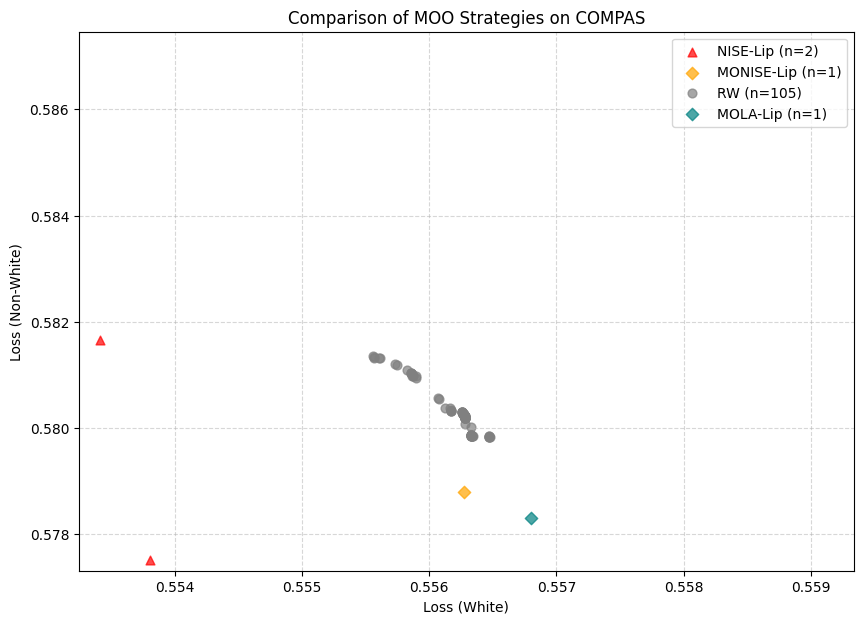


Runtime Comparison:
NISE-Lip: 120.03 s
MONISE-Lip: 120.05 s
RW: 120.01 s
MOLA-Lip: 120.02 s


In [ ]:
plt.figure(figsize=(10, 7))

colors = {'RW': 'gray', 'NISE': 'blue', 'NISE-Lip': 'red', 'RW-Lip': 'green', 'MONISE-Lip': 'orange', 'MOLA-Lip': 'teal'}
markers = {'RW': 'o', 'NISE': 'x', 'NISE-Lip': '^', 'RW-Lip': 's', 'MONISE-Lip': 'D', 'MOLA-Lip': 'D'}

for key, res in results.items():
    objs = get_objectives(res)
    plt.scatter(
        objs[:, 0], objs[:, 1], 
        label=f"{key} (n={len(objs)})", 
        c=colors[key], marker=markers[key], s=40, alpha=0.7 
    )

plt.xlabel('Loss (White)')
plt.ylabel('Loss (Non-White)')
plt.title('Comparison of MOO Strategies on COMPAS')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlim(None, reference_point[0])
plt.ylim(None, reference_point[1])
plt.show()

# Print Runtimes
print("\nRuntime Comparison:")
for key, res in results.items():
    print(f"{key}: {res.fit_runtime:.2f} s")

In [ ]:
for i, a in results.items():
    print(i)

NISE-Lip
MONISE-Lip
RW
MOLA-Lip


KeyboardInterrupt: 

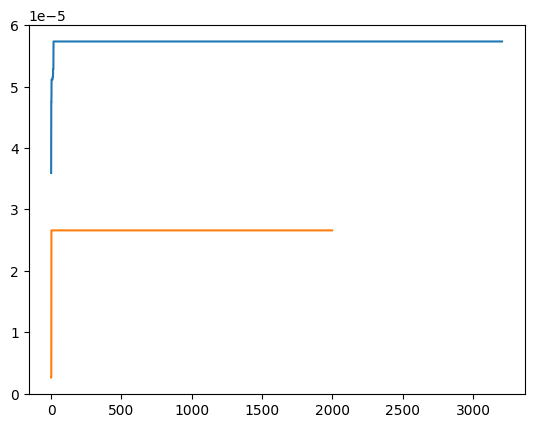

In [ ]:
from machinemoo.analysis.metrics import compute_hypervolume_progress

for key, res in results.items():
    objs = get_history_objectives(res)
    hv_values = compute_hypervolume_progress(objs, reference_point)
    plt.plot(hv_values, label=key)

plt.xlabel('Number of Solutions')
plt.ylabel('Hypervolume')
plt.title('Hypervolume Progression')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()